In [2]:
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
dataset = pd.read_csv(filepath_or_buffer="./ml_sample_data_snapsoft.csv")

In [ ]:
# Possible outliers (carlength, cylindernumber, horsepower - 10 missing; mean vs 50% - seems ok)
dataset.describe()

,car_ID,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
count,245.000000,245.000000,235.000000,245.000000,245.000000,245.000000,235.000000,245.000000,245.000000,235.000000,245.000000,245.000000,245.000000,245.000000
mean,123.000000,98.550204,173.640426,65.838367,53.631429,2544.187755,4.365957,126.310204,10.113184,103.157447,5120.204082,25.236735,30.848980,13102.655784
std,70.869599,5.821847,11.967236,2.052447,2.465772,502.330860,1.038835,40.210431,3.988802,38.420034,472.447802,6.460558,6.773082,7803.824961
min,1.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,62.000000,94.500000,166.300000,64.200000,51.600000,2169.000000,4.000000,98.000000,8.500000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,123.000000,96.600000,173.000000,65.400000,53.900000,2410.000000,4.000000,120.000000,9.000000,95.000000,5200.000000,24.000000,30.000000,10080.000000
75%,184.000000,101.200000,180.200000,66.500000,55.500000,2912.000000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,245.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [29]:
# Review dataset
features = dataset.columns
data_types = dataset.dtypes
dataset_info = dataset.info()
print(dataset.isnull().sum())
print(dataset.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_id             245 non-null    int64  
 1   carname            235 non-null    str    
 2   ownername          245 non-null    str    
 3   owneremail         245 non-null    str    
 4   dealershipaddress  245 non-null    str    
 5   saledate           245 non-null    str    
 6   iban               245 non-null    str    
 7   fueltype           235 non-null    str    
 8   aspiration         245 non-null    str    
 9   doornumber         245 non-null    str    
 10  carbody            235 non-null    str    
 11  drivewheel         245 non-null    str    
 12  enginelocation     235 non-null    str    
 13  wheelbase          245 non-null    float64
 14  color              245 non-null    str    
 15  carlength          235 non-null    float64
 16  carwidth           245 non-null    fl

In [ ]:
# Preprocess data
dataset.columns = (
    dataset.columns
    .str.strip()
    .str.lower()
)

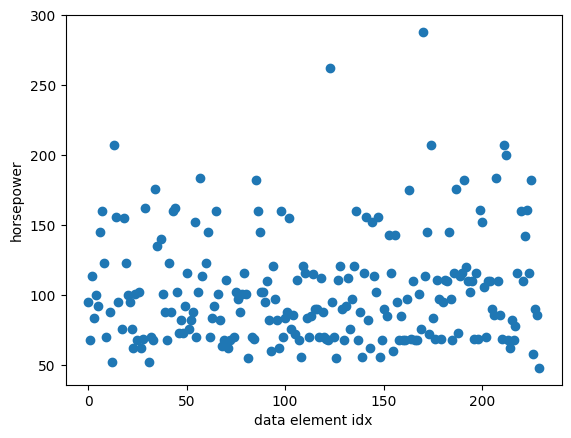

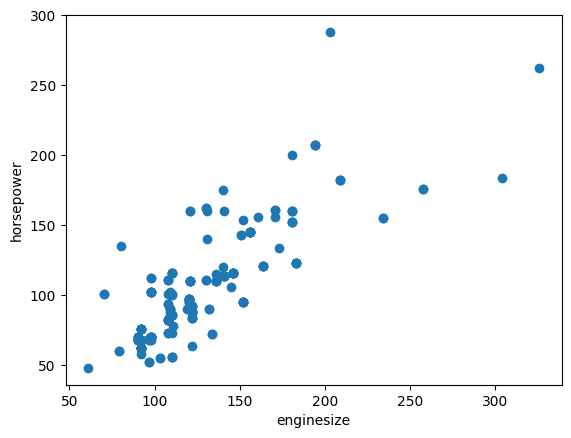

In [36]:
# Visualize the data
def plot_feature(dataset, feature, number_of_points_to_plot=230):
    plt.xlabel("data element idx")
    plt.ylabel(feature)

    random_examples = dataset.sample(n=number_of_points_to_plot)
    plt.scatter(list(range(number_of_points_to_plot)), random_examples[feature])
    plt.show()


def plot_two_features(dataset, feature_1, feature_2, number_of_points_to_plot=230):
    plt.xlabel(feature_1)
    plt.ylabel(feature_2)

    random_examples = dataset.sample(n=number_of_points_to_plot)
    plt.scatter(random_examples[feature_1], random_examples[feature_2])

    plt.show()

plot_feature(dataset=dataset, feature="horsepower")
plot_two_features(dataset=dataset, feature_1="enginesize", feature_2="horsepower")